# Exploratory Data Analysis: Maternal Postnatal Care in Kenya

## Project question

Which characteristics are associated with women missing timely postnatal care (PNC) within two days after childbirth?

This notebook uses straightforward `pandas`, `matplotlib`, and `seaborn` code. The goal is to understand the cleaned data before building a classification model.

### Target variable

- `0` = received timely PNC
- `1` = missed timely PNC

> The analysis describes relationships in the data. It does not prove that any variable causes a woman to miss PNC.

## 1. Import libraries

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 30)
sns.set_theme(style="whitegrid", palette="deep")

TARGET = "missed_timely_pnc"
target_labels = {0: "Received timely PNC", 1: "Missed timely PNC"}

## 2. Load the cleaned dataset

In [2]:
current_folder = Path.cwd().resolve()
folders_to_check = [current_folder, *current_folder.parents]

possible_paths = []
for folder in folders_to_check:
    possible_paths.extend([
        folder / "maternal_pnc_visualization_data.csv",
        folder / "data" / "processed" / "maternal_pnc_visualization_data.csv",
    ])

csv_path = next((path for path in possible_paths if path.exists()), None)

if csv_path is None:
    raise FileNotFoundError("Could not find maternal_pnc_visualization_data.csv")

df = pd.read_csv(csv_path)

print(f"File: {csv_path}")
print(f"The dataset has {df.shape[0]:,} rows and {df.shape[1]} columns.")
display(df.head())

File: C:\Users\USER\Downloads\Capstone\maternal_pnc_visualization_data.csv
The dataset has 10,505 rows and 18 columns.


,cluster_id,sample_weight,county_code,pregnancy_outcome,maternal_age,county_name,residence,education_level,wealth_quintile,children_ever_born,marital_status,currently_working,pregnancy_intention,first_anc_month,anc_visits,delivery_place,caesarean_delivery,missed_timely_pnc
0,480,0.827770,14,Live birth,38,Embu,Rural,Higher,Richer,3,Married,Yes,Wanted then,3.0,6.0,Private facility,Yes,0
1,1495,0.832490,43,Live birth,23,Homa Bay,Urban,Secondary,Richest,1,Married,Yes,Wanted then,6.0,3.0,Private facility,Yes,0
2,1033,0.471916,30,Live birth,35,Baringo,Rural,Secondary,Poorest,6,Married,No,Wanted then,3.0,6.0,Public facility,No,0
3,1198,1.090190,34,Live birth,33,Kajiado,Rural,Primary,Poorest,5,Married,No,Wanted then,3.0,6.0,Home,No,0
4,722,1.528534,21,Live birth,24,Murang'a,Rural,Higher,Middle,3,Living with partner,No,Wanted later,6.0,4.0,Public facility,No,1


## 3. Understand the structure of the data

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10505 entries, 0 to 10504
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   cluster_id           10505 non-null  int64  
 1   sample_weight        10505 non-null  float64
 2   county_code          10505 non-null  int64  
 3   pregnancy_outcome    10505 non-null  str    
 4   maternal_age         10505 non-null  int64  
 5   county_name          10505 non-null  str    
 6   residence            10505 non-null  str    
 7   education_level      10505 non-null  str    
 8   wealth_quintile      10505 non-null  str    
 9   children_ever_born   10505 non-null  int64  
 10  marital_status       10505 non-null  str    
 11  currently_working    10505 non-null  str    
 12  pregnancy_intention  10505 non-null  str    
 13  first_anc_month      10108 non-null  float64
 14  anc_visits           10495 non-null  float64
 15  delivery_place       10505 non-null  str    
 1

In [4]:
quality_summary = pd.DataFrame({
    "Check": [
        "Number of rows",
        "Number of columns",
        "Exact duplicate rows",
        "Missing target values",
        "Target values",
    ],
    "Result": [
        len(df),
        df.shape[1],
        df.duplicated().sum(),
        df[TARGET].isna().sum(),
        sorted(df[TARGET].unique()),
    ],
})

display(quality_summary)

,Check,Result
0,Number of rows,10505
1,Number of columns,18
2,Exact duplicate rows,3
3,Missing target values,0
4,Target values,"[0, 1]"


In [5]:
numeric_columns = [
    "maternal_age",
    "children_ever_born",
    "first_anc_month",
    "anc_visits",
]

categorical_columns = [
    "pregnancy_outcome",
    "county_name",
    "residence",
    "education_level",
    "wealth_quintile",
    "marital_status",
    "currently_working",
    "pregnancy_intention",
    "delivery_place",
    "caesarean_delivery",
]

analysis_only_columns = ["cluster_id", "sample_weight", "county_code"]

print("Numeric predictors:", numeric_columns)
print("Categorical predictors:", categorical_columns)
print("Analysis-only columns:", analysis_only_columns)

display(df[numeric_columns].describe().T)

Numeric predictors: ['maternal_age', 'children_ever_born', 'first_anc_month', 'anc_visits']
Categorical predictors: ['pregnancy_outcome', 'county_name', 'residence', 'education_level', 'wealth_quintile', 'marital_status', 'currently_working', 'pregnancy_intention', 'delivery_place', 'caesarean_delivery']
Analysis-only columns: ['cluster_id', 'sample_weight', 'county_code']


,count,mean,std,min,25%,50%,75%,max
maternal_age,10505.0,28.258924,6.612620,15.0,23.0,27.0,33.0,49.0
children_ever_born,10505.0,3.158401,2.222197,0.0,1.0,3.0,4.0,14.0
first_anc_month,10108.0,4.437178,1.628416,1.0,3.0,4.0,6.0,10.0
anc_visits,10495.0,4.059266,1.820545,0.0,3.0,4.0,5.0,20.0


### Data-quality interpretation

The cleaned file contains 10,505 observations and a complete binary target. `cluster_id`, `sample_weight`, and `county_code` are useful for analysis, but they are not treated as ordinary model predictors. Exact duplicate rows are not automatically removed because the dataset no longer contains a woman ID; two different women may share the same recorded characteristics.

## 4. Check missing values

Missing values are reported in a table only.No visualization on missingness, and no fill missing values during EDA. Imputation happens later, after the train/test split.

In [6]:
missing_values = pd.DataFrame({
    "Missing values": df.isna().sum(),
    "Missing percentage": (df.isna().mean() * 100).round(2),
})

display(missing_values[missing_values["Missing values"] > 0])

,Missing values,Missing percentage
first_anc_month,397,3.78
anc_visits,10,0.10




Missingness is limited to two ANC variables. `first_anc_month` has 397 missing values (3.78%), while `anc_visits` has 10 missing values (0.10%). These values should be handled inside the future modelling pipeline so that information from the test set does not leak into training.

## 5. Explore the target variable

We first examine how many women received timely PNC and how many missed it.

,Outcome,Count,Percentage
0,Received timely PNC,7814,74.4
1,Missed timely PNC,2691,25.6


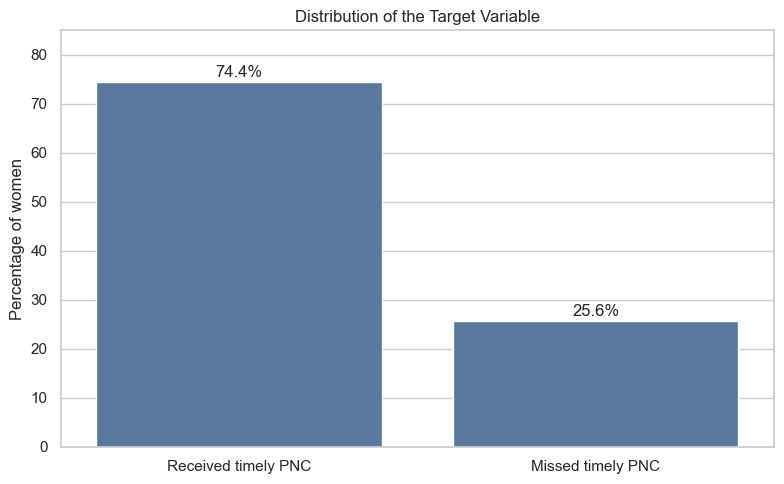

In [7]:
target_summary = df[TARGET].value_counts().sort_index().reset_index()
target_summary.columns = [TARGET, "Count"]
target_summary["Outcome"] = target_summary[TARGET].map(target_labels)
target_summary["Percentage"] = (target_summary["Count"] / len(df) * 100).round(1)

display(target_summary[["Outcome", "Count", "Percentage"]])

plt.figure(figsize=(8, 5))
ax = sns.barplot(data=target_summary, x="Outcome", y="Percentage", color="#4C78A8")
plt.title("Distribution of the Target Variable")
plt.xlabel("")
plt.ylabel("Percentage of women")

for index, value in enumerate(target_summary["Percentage"]):
    ax.text(index, value + 1, f"{value:.1f}%", ha="center")

plt.ylim(0, 85)
plt.tight_layout()
plt.show()



About 74.4% of women received timely PNC, while 25.6% missed it. The target is moderately imbalanced. A model could obtain high accuracy by mostly predicting the larger class, so later evaluation should include recall, precision, F1-score, and PR-AUC—not accuracy alone.

## 6. Survey-weighted target estimate

The DHS sample weight adjusts for unequal sampling probabilities. We compare the raw sample percentage with the weighted descriptive estimate.

,Estimate,Missed timely PNC (%)
0,Unweighted sample,25.6
1,Survey-weighted,21.5


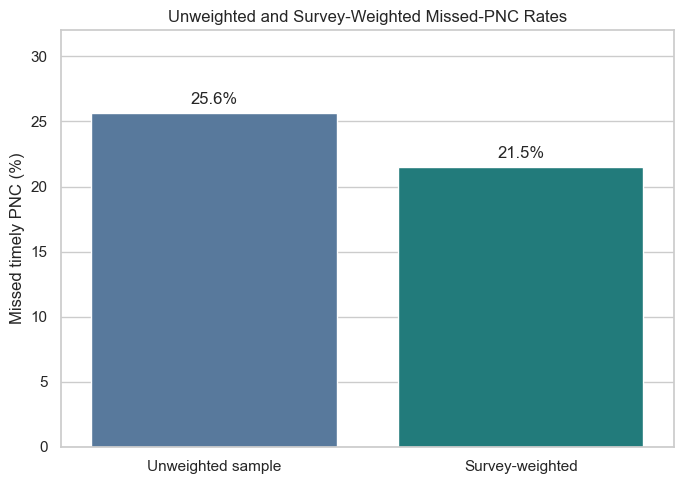

In [8]:
unweighted_rate = df[TARGET].mean() * 100
weighted_rate = np.average(df[TARGET], weights=df["sample_weight"]) * 100

rate_comparison = pd.DataFrame({
    "Estimate": ["Unweighted sample", "Survey-weighted"],
    "Missed timely PNC (%)": [unweighted_rate, weighted_rate],
})

display(rate_comparison.round(1))

plt.figure(figsize=(7, 5))
ax = sns.barplot(
    data=rate_comparison,
    x="Estimate",
    y="Missed timely PNC (%)",
    hue="Estimate",
    palette=["#4C78A8", "#138A8A"],
    legend=False,
)
plt.title("Unweighted and Survey-Weighted Missed-PNC Rates")
plt.xlabel("")
plt.ylim(0, 32)

for index, value in enumerate(rate_comparison["Missed timely PNC (%)"]):
    ax.text(index, value + 0.7, f"{value:.1f}%", ha="center")

plt.tight_layout()
plt.show()

### Interpretation

The missed-PNC rate is 25.6% in the modelling sample and approximately 21.5% after applying the DHS sample weights. The weighted figure is more suitable for a population-level description, while the unweighted figure describes the rows used for modelling.

## 7. Univariate analysis of numeric predictors

Univariate analysis examines one variable at a time. Histograms help us understand the shape, centre, spread, and unusual values in numeric variables.

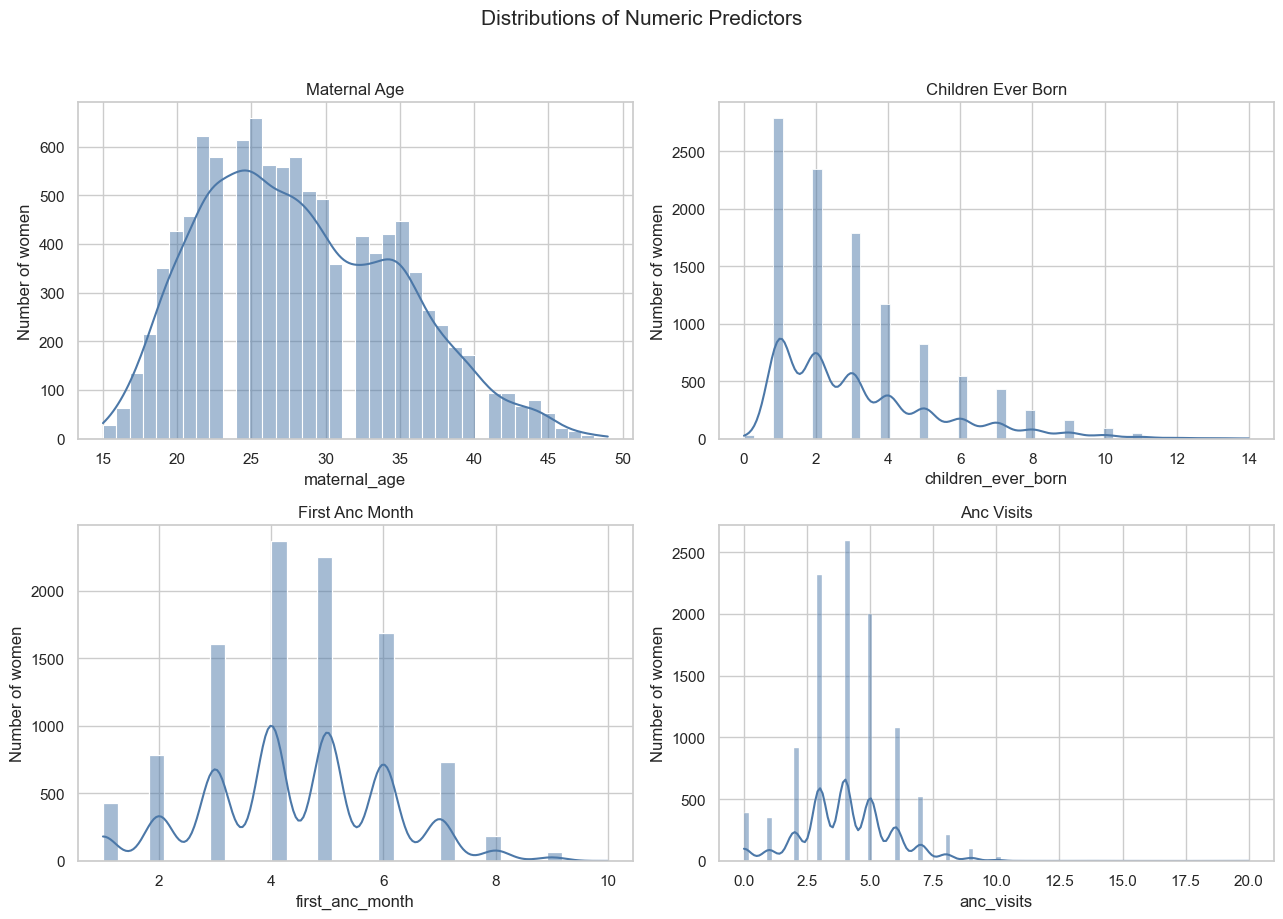

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

for column, axis in zip(numeric_columns, axes.flatten()):
    sns.histplot(data=df, x=column, bins="auto", kde=True, ax=axis, color="#4C78A8")
    axis.set_title(column.replace("_", " ").title())
    axis.set_ylabel("Number of women")

plt.suptitle("Distributions of Numeric Predictors", fontsize=15, y=1.02)
plt.tight_layout()
plt.show()



Maternal age is spread across the reproductive age range, while `children_ever_born` is right-skewed because most women have fewer children and a smaller number have high parity. ANC timing is concentrated in the earlier and middle months of pregnancy. ANC visits also show a concentration around commonly recommended attendance levels, with a smaller number of high values.

## 8. Univariate analysis of demographic and socioeconomic predictors

Count plots show how women are distributed across important background categories.

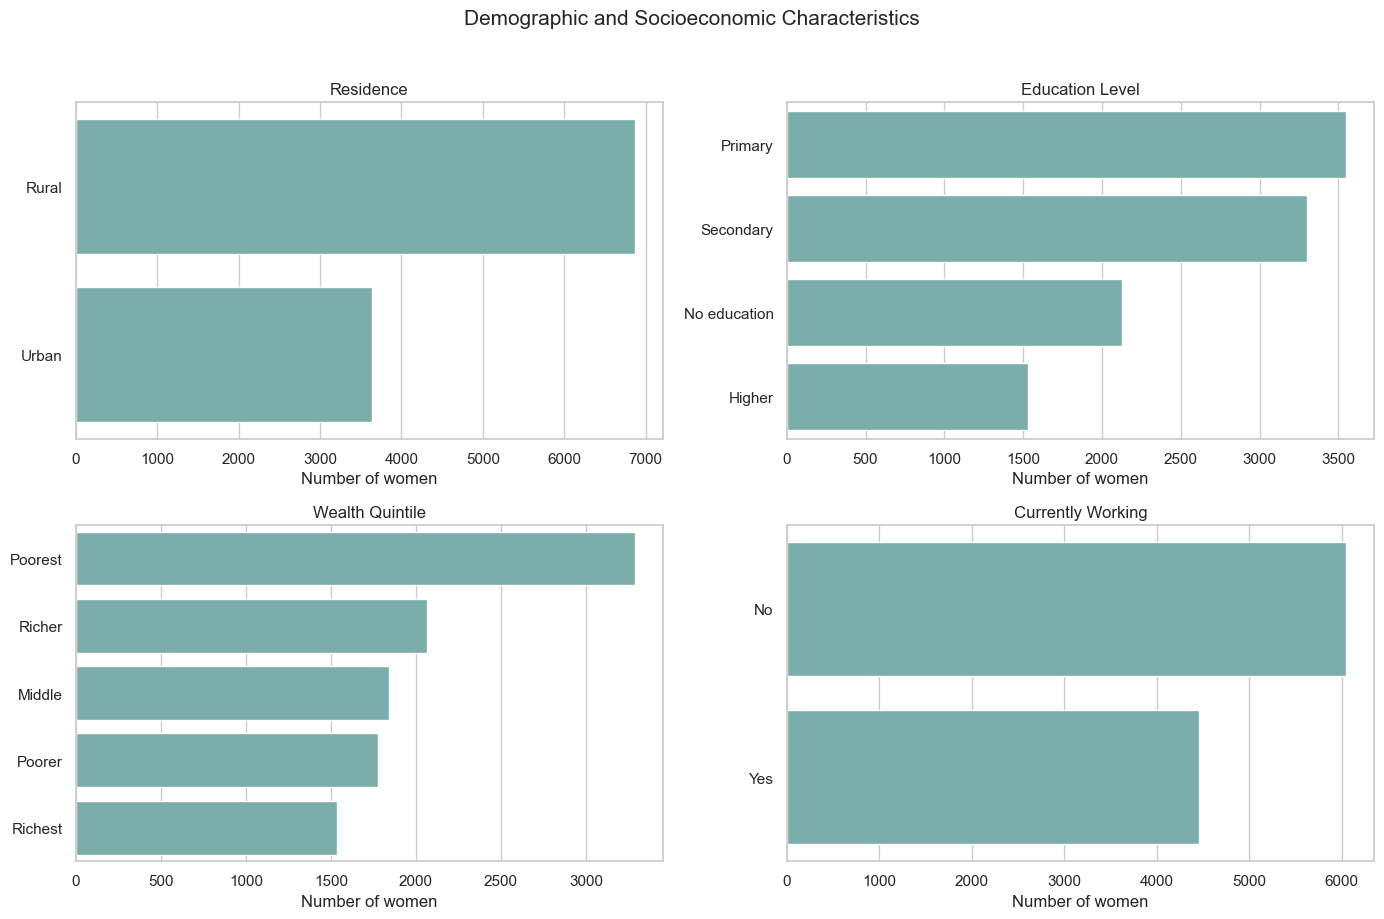

In [10]:
demographic_columns = ["residence", "education_level", "wealth_quintile", "currently_working"]

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

for column, axis in zip(demographic_columns, axes.flatten()):
    order = df[column].value_counts().index
    sns.countplot(data=df, y=column, order=order, ax=axis, color="#72B7B2")
    axis.set_title(column.replace("_", " ").title())
    axis.set_xlabel("Number of women")
    axis.set_ylabel("")

plt.suptitle("Demographic and Socioeconomic Characteristics", fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

This section describes the demographic and socioeconomic composition of the sample. It shows how women are distributed by residence, education, wealth, and employment. These charts show group sizes only; they do not yet show which groups have higher missed-PNC rates.

## 9. Univariate analysis of pregnancy and healthcare predictors

These variables describe pregnancy intention, pregnancy outcome, delivery setting, and caesarean delivery.

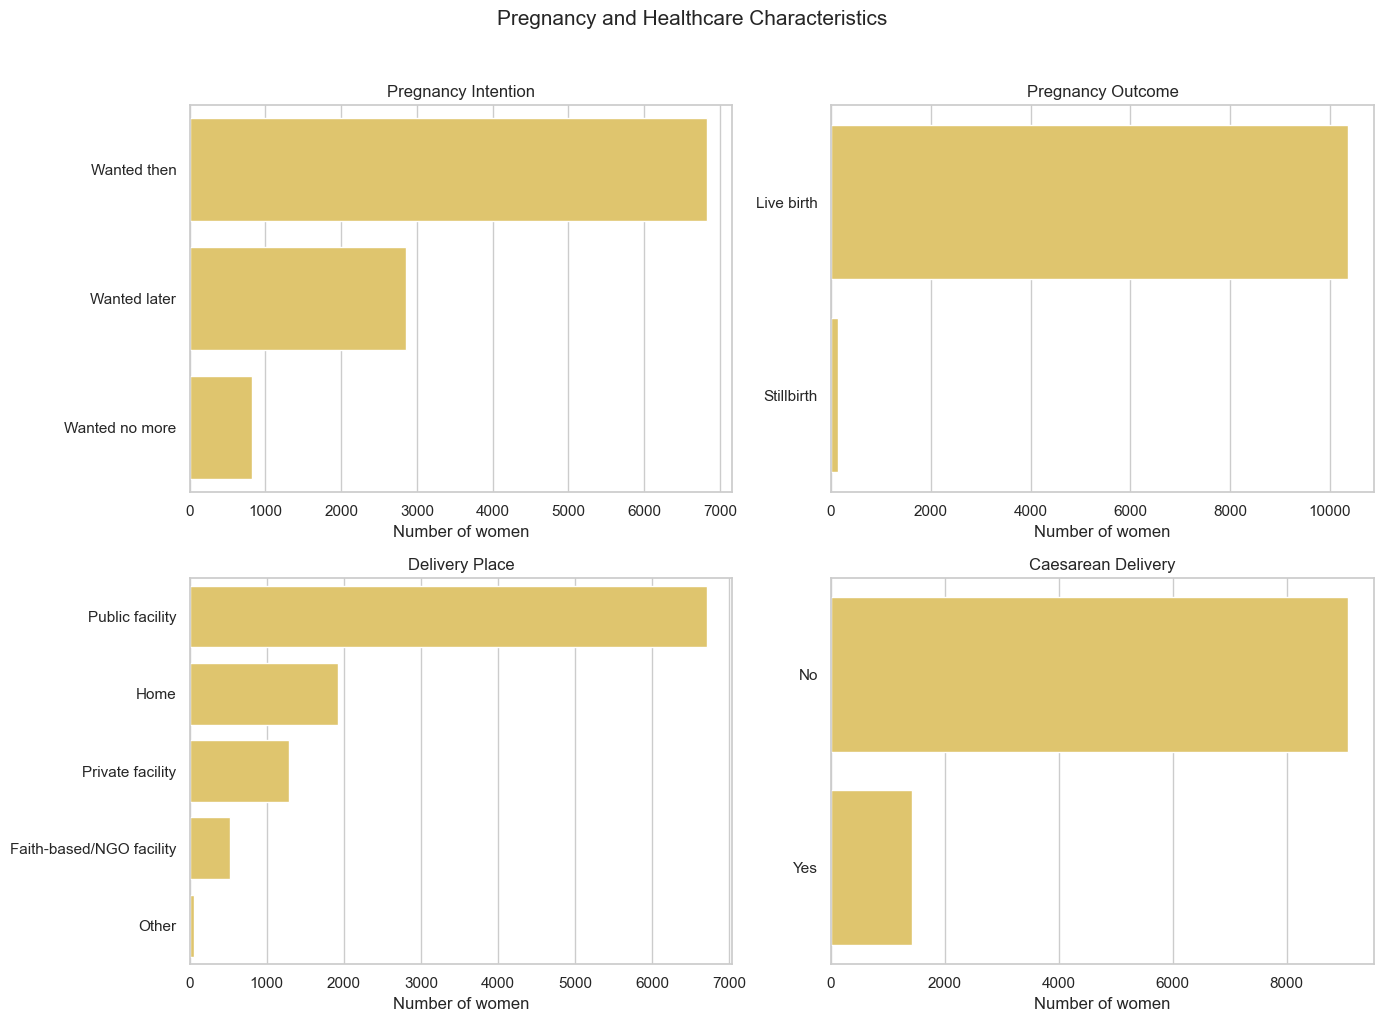

In [11]:
care_columns = ["pregnancy_intention", "pregnancy_outcome", "delivery_place", "caesarean_delivery"]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for column, axis in zip(care_columns, axes.flatten()):
    order = df[column].value_counts().index
    sns.countplot(data=df, y=column, order=order, ax=axis, color="#F2CF5B")
    axis.set_title(column.replace("_", " ").title())
    axis.set_xlabel("Number of women")
    axis.set_ylabel("")

plt.suptitle("Pregnancy and Healthcare Characteristics", fontsize=15, y=1.02)
plt.tight_layout()
plt.show()



Most pregnancies in the dataset ended in a live birth, and public facilities account for a large share of deliveries. Home delivery and stillbirth are smaller groups, so their percentages should be interpreted together with their sample sizes. The category distributions also help identify levels that may need careful handling during train/test splitting and encoding.

## 10. Numeric predictors compared with the target

Boxplots compare the distributions for women who received timely PNC and women who missed it.

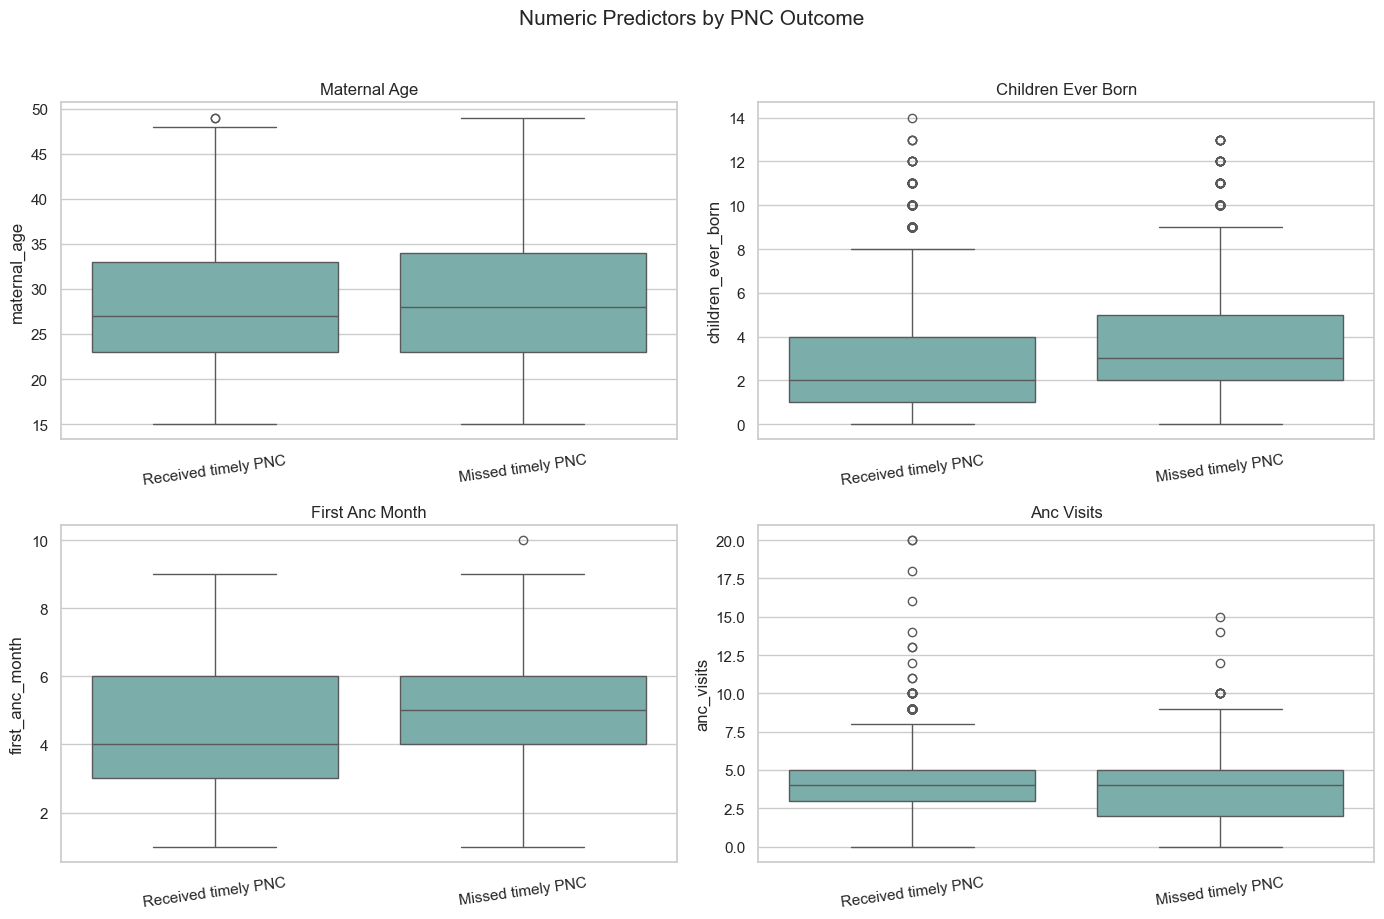

In [12]:
plot_data = df.copy()
plot_data["PNC outcome"] = plot_data[TARGET].map(target_labels)

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

for column, axis in zip(numeric_columns, axes.flatten()):
    sns.boxplot(data=plot_data, x="PNC outcome", y=column, ax=axis, color="#72B7B2")
    axis.set_title(column.replace("_", " ").title())
    axis.set_xlabel("")
    axis.tick_params(axis="x", rotation=8)

plt.suptitle("Numeric Predictors by PNC Outcome", fontsize=15, y=1.02)
plt.tight_layout()
plt.show()



The largest visible difference is in ANC visits: women who missed timely PNC generally attended fewer ANC visits. Maternal age and children ever born show more overlap between the two outcome groups. The boxplots suggest useful relationships, but they do not prove that a variable causes missed care.

## 11. Create a simple category-rate function

For categorical predictors, we calculate the percentage who missed timely PNC within each category. This is more useful than comparing raw missed-care counts when category sizes differ.

In [13]:
def missed_pnc_rate(data, column):
    result = (
        data.groupby(column, observed=False)[TARGET]
        .agg(Women="size", Missed="sum", Missed_rate="mean")
        .reset_index()
    )
    result["Missed_rate_percent"] = result["Missed_rate"] * 100
    return result

## 12. Delivery place and missed timely PNC

,delivery_place,Women,Missed,Missed_rate_percent
0,Faith-based/NGO facility,528,48,9.1
3,Private facility,1284,158,12.3
4,Public facility,6705,1133,16.9
2,Other,58,24,41.4
1,Home,1930,1328,68.8


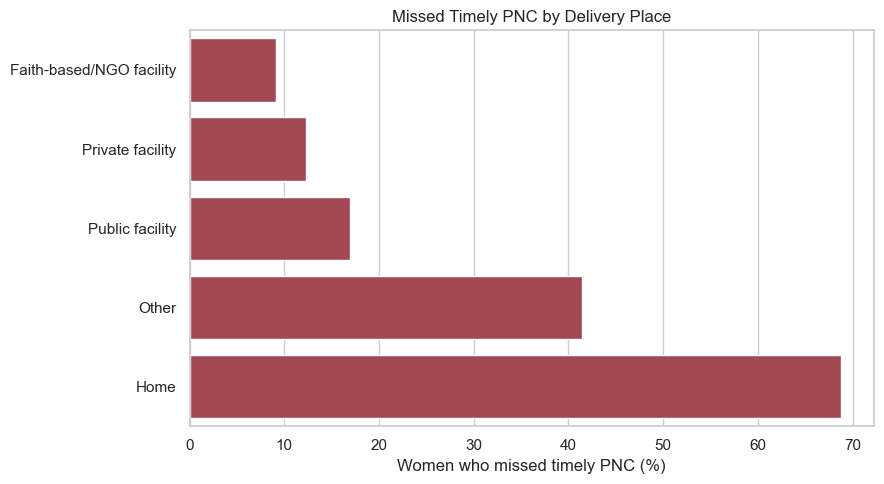

In [14]:
delivery_rates = missed_pnc_rate(df, "delivery_place").sort_values("Missed_rate_percent")
display(delivery_rates[["delivery_place", "Women", "Missed", "Missed_rate_percent"]].round(1))

plt.figure(figsize=(9, 5))
sns.barplot(data=delivery_rates, x="Missed_rate_percent", y="delivery_place", color="#B23A48")
plt.title("Missed Timely PNC by Delivery Place")
plt.xlabel("Women who missed timely PNC (%)")
plt.ylabel("")
plt.tight_layout()
plt.show()



Delivery place shows one of the clearest differences in the EDA. Approximately 68.8% of women who delivered at home missed timely PNC, compared with about 9.1% among women delivering in faith-based or NGO facilities. Delivery place may reflect access, distance, service availability, and the opportunity to receive a check before discharge.

## 13. Residence and missed timely PNC

,residence,Women,Missed,Missed_rate_percent
0,Rural,6870,2008,29.2
1,Urban,3635,683,18.8


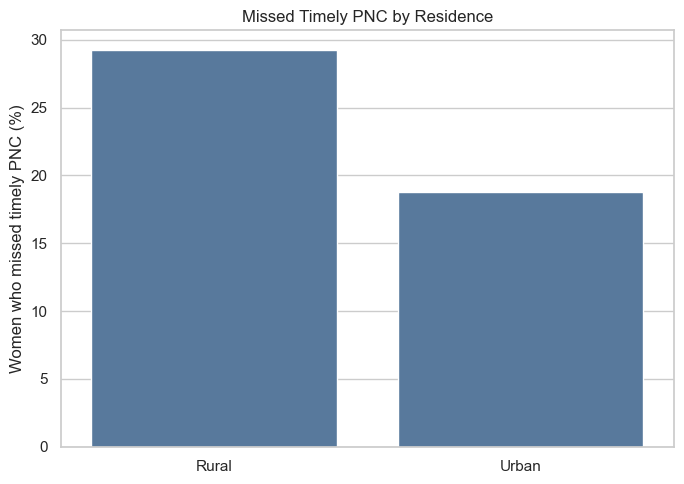

In [15]:
residence_rates = missed_pnc_rate(df, "residence")
display(residence_rates[["residence", "Women", "Missed", "Missed_rate_percent"]].round(1))

plt.figure(figsize=(7, 5))
ax = sns.barplot(data=residence_rates, x="residence", y="Missed_rate_percent", color="#4C78A8")
plt.title("Missed Timely PNC by Residence")
plt.xlabel("")
plt.ylabel("Women who missed timely PNC (%)")
plt.tight_layout()
plt.show()



As observed women in rural areas missed timely PNC as compared to those in urban areas. Any difference may reflect transport, distance to facilities, availability of services, or other socioeconomic factors. Residence should be interpreted alongside county, wealth, education, and delivery place.

## 14. Education and missed timely PNC

,education_level,Women,Missed,Missed_rate_percent
1,No education,2124,1103,51.9
2,Primary,3548,868,24.5
3,Secondary,3302,549,16.6
0,Higher,1531,171,11.2


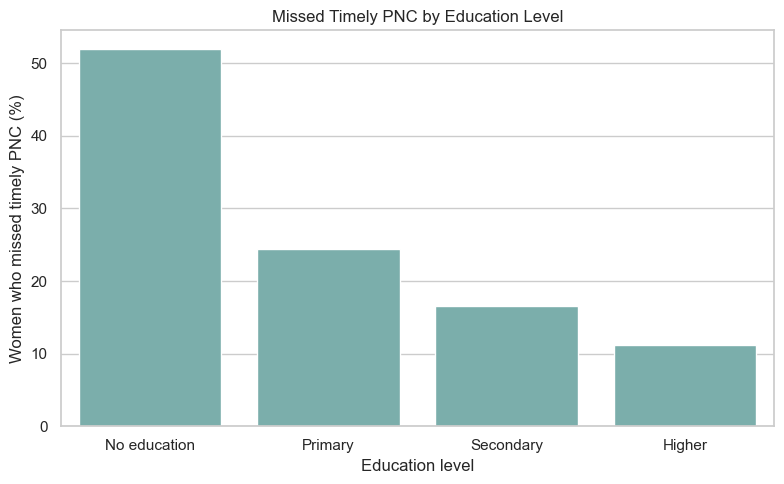

In [16]:
education_order = ["No education", "Primary", "Secondary", "Higher"]
education_rates = missed_pnc_rate(df, "education_level")
education_rates["education_level"] = pd.Categorical(
    education_rates["education_level"], categories=education_order, ordered=True
)
education_rates = education_rates.sort_values("education_level")
display(education_rates[["education_level", "Women", "Missed", "Missed_rate_percent"]].round(1))

plt.figure(figsize=(8, 5))
sns.barplot(data=education_rates, x="education_level", y="Missed_rate_percent", color="#72B7B2")
plt.title("Missed Timely PNC by Education Level")
plt.xlabel("Education level")
plt.ylabel("Women who missed timely PNC (%)")
plt.tight_layout()
plt.show()



Educated women did not miss timely PNC. Education may be related to health information, income, confidence navigating services, and residence. The observed pattern is an association and may overlap with wealth and geography.

## 15. Wealth and missed timely PNC

,wealth_quintile,Women,Missed,Missed_rate_percent
2,Poorest,3289,1409,42.8
1,Poorer,1775,416,23.4
0,Middle,1841,345,18.7
3,Richer,2064,367,17.8
4,Richest,1536,154,10.0


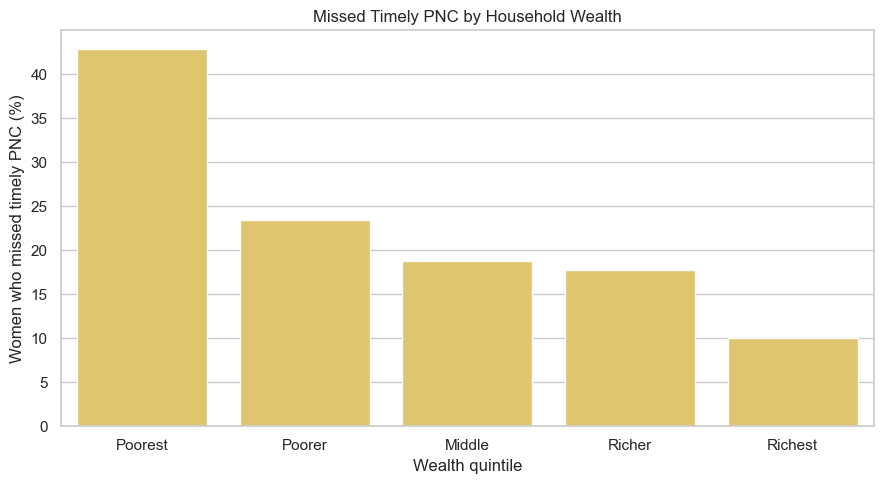

In [17]:
wealth_order = ["Poorest", "Poorer", "Middle", "Richer", "Richest"]
wealth_rates = missed_pnc_rate(df, "wealth_quintile")
wealth_rates["wealth_quintile"] = pd.Categorical(
    wealth_rates["wealth_quintile"], categories=wealth_order, ordered=True
)
wealth_rates = wealth_rates.sort_values("wealth_quintile")
display(wealth_rates[["wealth_quintile", "Women", "Missed", "Missed_rate_percent"]].round(1))

plt.figure(figsize=(9, 5))
sns.barplot(data=wealth_rates, x="wealth_quintile", y="Missed_rate_percent", color="#F2CF5B")
plt.title("Missed Timely PNC by Household Wealth")
plt.xlabel("Wealth quintile")
plt.ylabel("Women who missed timely PNC (%)")
plt.tight_layout()
plt.show()



As observed women not considered well of missed timely PNC. Wealth groups can differ in transport options, distance barriers, facility choice, and ability to pay indirect healthcare costs. If missed-PNC rates decline across wealth groups, that would support the idea that access and resources matter. The pattern should still be examined together with residence and education.

## 16. Pregnancy outcome and missed timely PNC

,pregnancy_outcome,Women,Missed,Missed_rate_percent
0,Live birth,10363,2638,25.5
1,Stillbirth,142,53,37.3


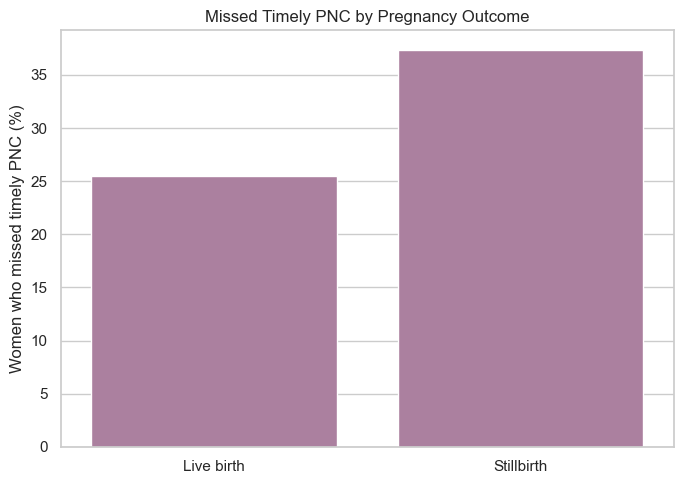

In [18]:
outcome_rates = missed_pnc_rate(df, "pregnancy_outcome")
display(outcome_rates[["pregnancy_outcome", "Women", "Missed", "Missed_rate_percent"]].round(1))

plt.figure(figsize=(7, 5))
sns.barplot(data=outcome_rates, x="pregnancy_outcome", y="Missed_rate_percent", color="#B279A2")
plt.title("Missed Timely PNC by Pregnancy Outcome")
plt.xlabel("")
plt.ylabel("Women who missed timely PNC (%)")
plt.tight_layout()
plt.show()

Women with stillbirths and live births show different missed-PNC rates, but the stillbirth group is much smaller. 
This comparison includes both live births and stillbirths because mothers require postnatal care after either outcome.

## 17. County-level comparison

County has 47 categories, so a horizontal chart is easier to read. We show all counties and retain the sample size in the table.

,county_name,Women,Missed,Missed_rate_percent
14,Kirinyaga,139,10,7.2
3,Busia,244,18,7.4
5,Embu,145,11,7.6
16,Kisumu,244,21,8.6
21,Machakos,157,14,8.9
44,Vihiga,178,16,9.0
33,Nyamira,140,14,10.0
4,Elgeyo-Marakwet,210,22,10.5
18,Kwale,226,24,10.6
12,Kiambu,192,23,12.0


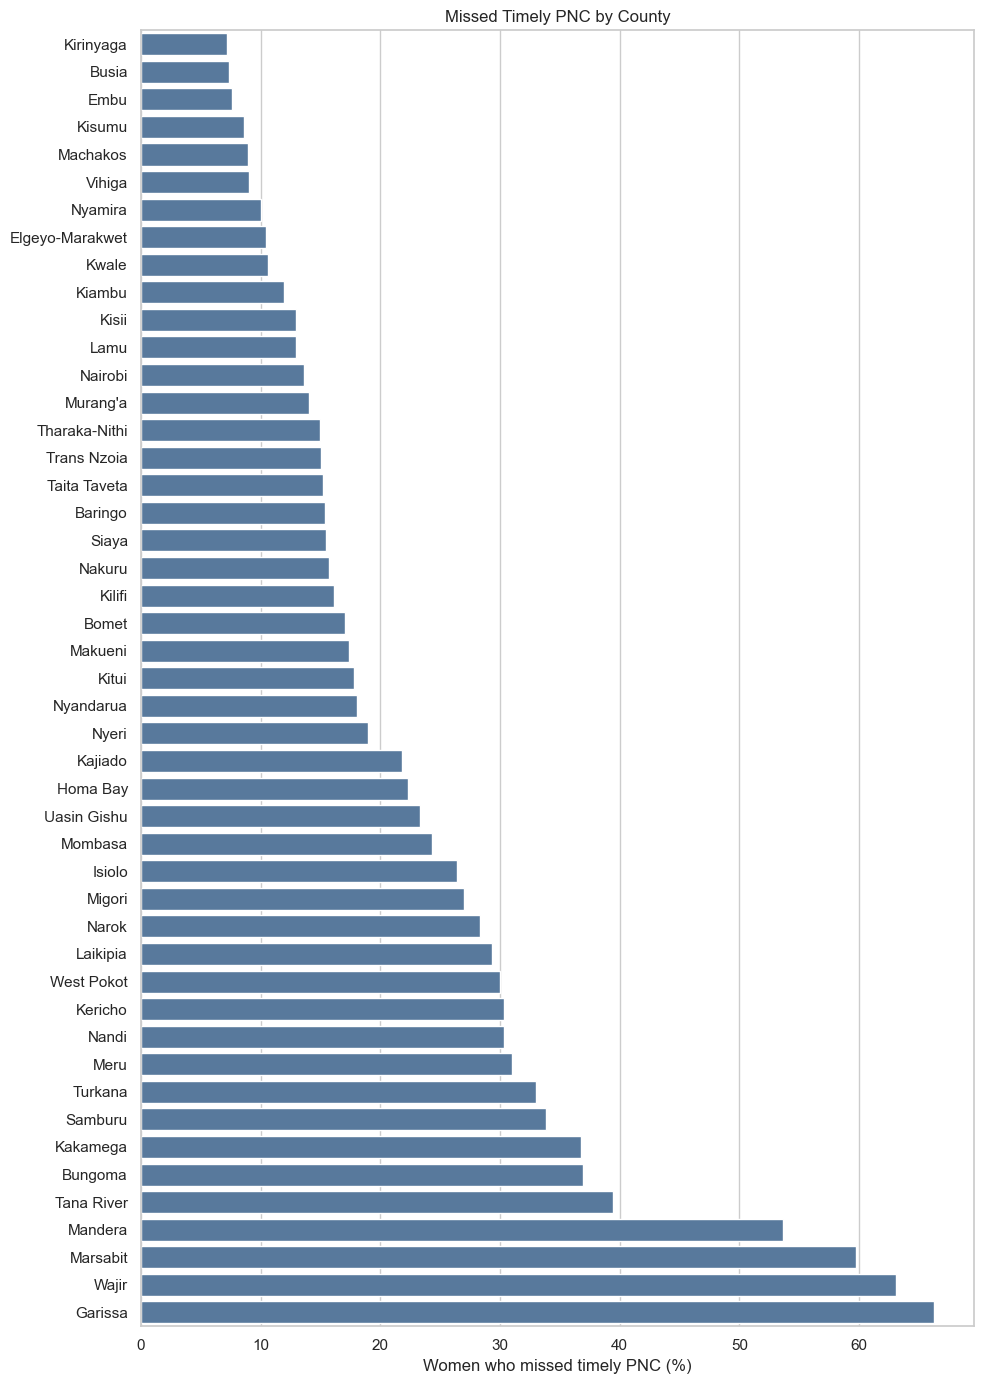

In [19]:
county_rates = missed_pnc_rate(df, "county_name").sort_values("Missed_rate_percent")
display(county_rates[["county_name", "Women", "Missed", "Missed_rate_percent"]].round(1))

plt.figure(figsize=(10, 14))
sns.barplot(data=county_rates, x="Missed_rate_percent", y="county_name", color="#4C78A8")
plt.title("Missed Timely PNC by County")
plt.xlabel("Women who missed timely PNC (%)")
plt.ylabel("")
plt.tight_layout()
plt.show()

Missed timely PNC varies widely by county. Garissa has the highest observed rate, while Kirinyaga has the lowest, suggesting strong geographic differences in access to postnatal care.

## 18. Correlation among numeric predictors

The correlation heatmap shows how the numeric predictors move together. Values near `1` indicate a positive relationship, values near `-1` indicate a negative relationship, and values near `0` indicate little linear relationship.

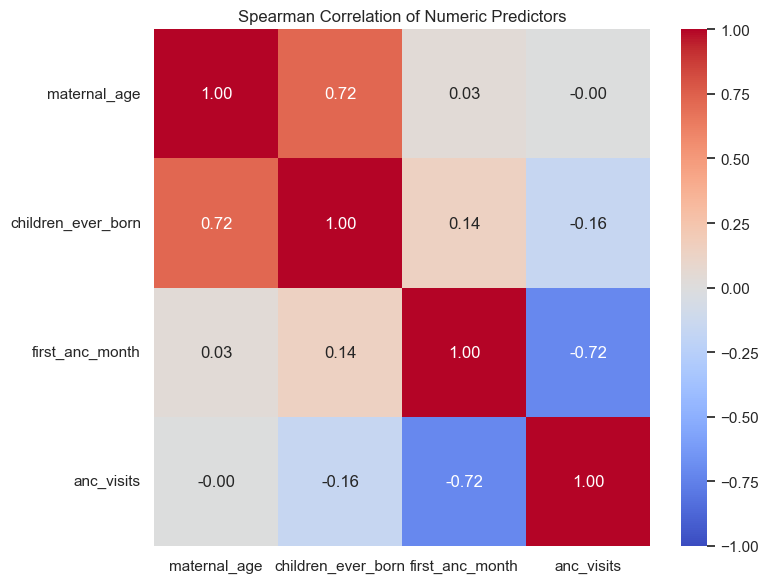

In [20]:
correlation_matrix = df[numeric_columns].corr(method="spearman")

plt.figure(figsize=(8, 6))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
)
plt.title("Spearman Correlation of Numeric Predictors")
plt.tight_layout()
plt.show()

The heatmap shows relationships among the numeric predictors. Maternal age is positively related to the number of children ever born, while starting ANC earlier is generally associated with attending more ANC visits. No correlation is strong enough to suggest removing a variable.

## 19. Summary of main findings

1. **The outcome is imbalanced:** 25.6% of the modelling sample missed timely PNC.
2. **The weighted estimate is lower:** approximately 21.5% after applying DHS sample weights.
3. **Delivery place is an important signal:** home delivery has a particularly high missed-care rate.
4. **ANC engagement matters:** women missing timely PNC generally attended fewer ANC visits.
5. **Geography matters:** missed-care rates vary across counties, suggesting local service context is important.
6. **Some predictors overlap:** age relates to number of children, while education, wealth, residence, and county may describe connected aspects of access.
